In [5]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# 1. Generate 200 random Mall Customers
np.random.seed(42)
age = np.random.randint(18, 70, 200)
income = np.random.randint(15, 150, 200) # $15k to $150k
score = np.random.randint(1, 100, 200)   # Shopping score from 1 to 99

df_customers = pd.DataFrame({
    'Age': age,
    'Annual_Income_k': income,
    'Spending_Score': score
})

# 2. Prepare X (We only have Features!)
# Notice we are leaving out 'Age' for now to keep it simple, just using Money & Score
X = df_customers[['Annual_Income_k', 'Spending_Score']]

# 3. Initialize the Model
# We are asking the math to find exactly 3 groups. n_init=10 is a best-practice setting.
model_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# 4. Fit the model AND predict the labels at the same time
# The model will look at the data, find 3 centers, and assign every row a label (0, 1, or 2)
customer_segments = model_kmeans.fit_predict(X)

# 5. Add the labels back into our original "Excel" sheet!
df_customers['Segment_Group'] = customer_segments

print("--- CLUSTERING COMPLETE ---")
print("First 10 Customers and their assigned Segments:\n")
print(df_customers.head(10))

--- CLUSTERING COMPLETE ---
First 10 Customers and their assigned Segments:

   Age  Annual_Income_k  Spending_Score  Segment_Group
0   56               76               1              2
1   69               65              16              0
2   46               73              61              0
3   32              132              64              1
4   60              110              63              1
5   25              127              69              1
6   38               76              22              0
7   56               66              93              0
8   36               26              67              0
9   40               53              76              0


C:\Users\swarn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


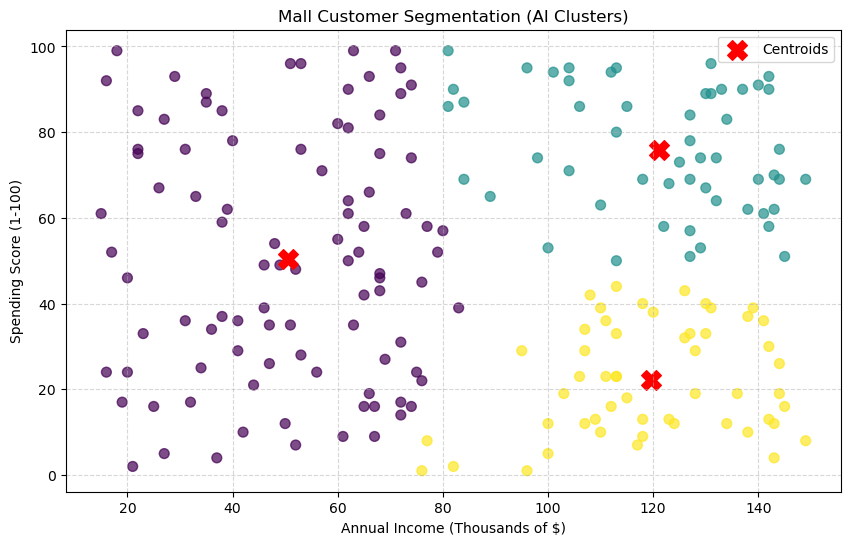

In [6]:
import matplotlib.pyplot as plt

# 1. Set the size of the canvas (width, height)
plt.figure(figsize=(10, 6))

# 2. Plot the customers (The Dots)
# We plot Income on the X-axis and Score on the Y-axis.
# We tell it to color (c) the dots based on their 'Segment_Group' number!
plt.scatter(df_customers['Annual_Income_k'], 
            df_customers['Spending_Score'], 
            c=df_customers['Segment_Group'], 
            cmap='viridis',  # 'viridis' is a built-in color palette
            s=50,            # Size of the dots
            alpha=0.7)       # Make them slightly transparent

# 3. Plot the Centroids (The Centers)
# model.cluster_centers_ holds the exact X, and Y coordinates that the AI calculated
centroids = model_kmeans.cluster_centers_

# We plot them as giant red 'X' markers so they stand out
plt.scatter(centroids[:, 0], centroids[:, 1], 
            c='red', s=200, marker='X', label='Centroids')

# 4. Add titles and labels to make it look professional
plt.title('Mall Customer Segmentation (AI Clusters)')
plt.xlabel('Annual Income (Thousands of $)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# 5. Show the masterpiece!
plt.show()